# Rumahku House Prices — EDA, Preprocessing, Modeling, Evaluasi

Notebook ini mencakup:
- **Bagian C** — Eksplorasi dan Pra-pemrosesan Data
- **Bagian D** — Penerapan Machine Learning (Regresi)
- **Bagian E** — Evaluasi Model

Target: memprediksi `harga_jual` properti berdasarkan fitur fisik dan lokasi.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os
sys.path.append(os.path.abspath('../src'))

from preprocessing import (
    NUMERIC_FEATURES, BINARY_FEATURES, ORDINAL_FEATURES, ORDINAL_ORDER,
    NOMINAL_FEATURES, TARGET, ALL_FEATURES,
    load_raw_data, clean_data, build_preprocessor, split_X_y,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 20)


## C.1 Memahami Struktur Dataset

Melihat dimensi data, tipe kolom, dan contoh baris untuk memahami apa yang sedang dianalisis
sebelum melakukan pembersihan apa pun.

In [6]:
df_raw = load_raw_data('../data/rumahku_house_prices.csv')
print('Ukuran data:', df_raw.shape)
df_raw.head()


Ukuran data: (5000, 13)


,id_properti,luas_tanah,luas_bangunan,kamar_tidur,kamar_mandi,jumlah_lantai,usia_bangunan,jarak_pusat_kota,kondisi_bangunan,tipe_properti,garasi,kota,harga_jual
0,PROP-1502,111.0,94.0,3,3,3,33.0,20.9,Buruk,Villa,1,Bandung,356.3
1,PROP-2587,116.0,71.0,3,3,3,19.0,23.9,Cukup,Rumah,1,Bandung,288.9
2,PROP-2654,678.0,309.0,2,1,2,32.0,5.3,Cukup,Rumah,1,Bandung,2024.1
3,PROP-1056,475.0,364.0,3,2,2,9.0,1.9,Cukup,Rumah,1,Surabaya,2197.9
4,PROP-0706,565.0,332.0,2,2,1,27.0,2.6,Buruk,Rumah,1,Bandung,1700.7


In [7]:
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id_properti       5000 non-null   object 
 1   luas_tanah        4950 non-null   float64
 2   luas_bangunan     4950 non-null   float64
 3   kamar_tidur       5000 non-null   int64  
 4   kamar_mandi       5000 non-null   int64  
 5   jumlah_lantai     5000 non-null   int64  
 6   usia_bangunan     4925 non-null   float64
 7   jarak_pusat_kota  4925 non-null   float64
 8   kondisi_bangunan  4950 non-null   object 
 9   tipe_properti     5000 non-null   object 
 10  garasi            5000 non-null   int64  
 11  kota              4975 non-null   object 
 12  harga_jual        4960 non-null   float64
dtypes: float64(5), int64(4), object(4)
memory usage: 507.9+ KB


In [9]:
df_raw.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id_properti,5000,5000,PROP-1502,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
luas_tanah,4950.0,NaN,NaN,NaN,427.287677,212.585879,60.0,248.0,422.0,611.75,800.0
luas_bangunan,4950.0,NaN,NaN,NaN,292.872121,159.120888,40.0,160.0,279.0,405.0,724.0
kamar_tidur,5000.0,NaN,NaN,NaN,3.2498,1.171527,1.0,3.0,3.0,4.0,6.0
kamar_mandi,5000.0,NaN,NaN,NaN,2.6558,1.009916,1.0,2.0,3.0,3.0,4.0
jumlah_lantai,5000.0,NaN,NaN,NaN,1.7142,0.724033,1.0,1.0,2.0,2.0,3.0
usia_bangunan,4925.0,NaN,NaN,NaN,19.823959,11.885525,0.0,9.0,20.0,30.0,40.0
jarak_pusat_kota,4925.0,NaN,NaN,NaN,15.228569,8.545714,0.5,7.8,15.4,22.6,30.0
kondisi_bangunan,4950,3,Baik,2464,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tipe_properti,5000,3,Rumah,3031,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## C.2 Mengecek Missing Value

Mengukur jumlah dan proporsi nilai kosong per kolom. Ini menentukan strategi imputasi yang
akan dipakai pada tahap pembersihan.

In [10]:
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_summary = pd.DataFrame({'jumlah_missing': missing, 'persentase(%)': missing_pct})
missing_summary = missing_summary[missing_summary['jumlah_missing'] > 0].sort_values('jumlah_missing', ascending=False)
missing_summary


,jumlah_missing,persentase(%)
usia_bangunan,75,1.5
jarak_pusat_kota,75,1.5
luas_tanah,50,1.0
luas_bangunan,50,1.0
kondisi_bangunan,50,1.0
harga_jual,40,0.8
kota,25,0.5


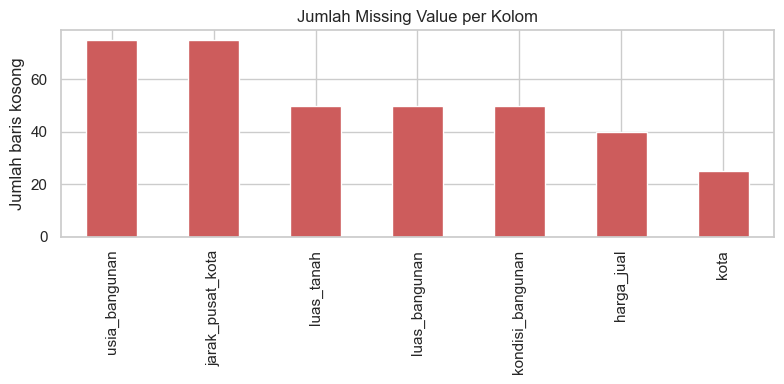

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
missing_summary['jumlah_missing'].plot(kind='bar', ax=ax, color='indianred')
ax.set_title('Jumlah Missing Value per Kolom')
ax.set_ylabel('Jumlah baris kosong')
plt.tight_layout()
plt.show()


**Interpretasi:** seluruh kolom yang memiliki missing value proporsinya kecil (< 1.5% dari
5.000 baris), sehingga imputasi (bukan penghapusan kolom) adalah strategi yang wajar. Khusus
`harga_jual` (variabel target) yang kosong tidak bisa diimputasi karena kita tidak boleh
"mengarang" ground truth untuk supervised learning — baris tersebut akan dibuang.

## C.3 Mengecek Data Duplikat

Duplikat dicek dua arah: baris yang identik persis di semua kolom, dan `id_properti` yang
duplikat (idealnya unik karena merepresentasikan satu properti).

In [12]:
print('Baris duplikat penuh:', df_raw.duplicated().sum())
print('id_properti duplikat:', df_raw['id_properti'].duplicated().sum())


Baris duplikat penuh: 0
id_properti duplikat: 0


**Interpretasi:** tidak ditemukan duplikat pada dataset ini. Langkah pengecekan tetap
dijalankan sebagai praktik baku preprocessing, dan kode pembersihan (`clean_data`) tetap
menyertakan `drop_duplicates()` untuk berjaga-jaga jika dataset diperbarui di kemudian hari.

## C.4 Mengecek Outlier

Fokus pada `harga_jual` (variabel target) karena outlier pada target paling berpengaruh
terhadap model regresi, terutama Linear Regression yang sensitif terhadap nilai ekstrem.

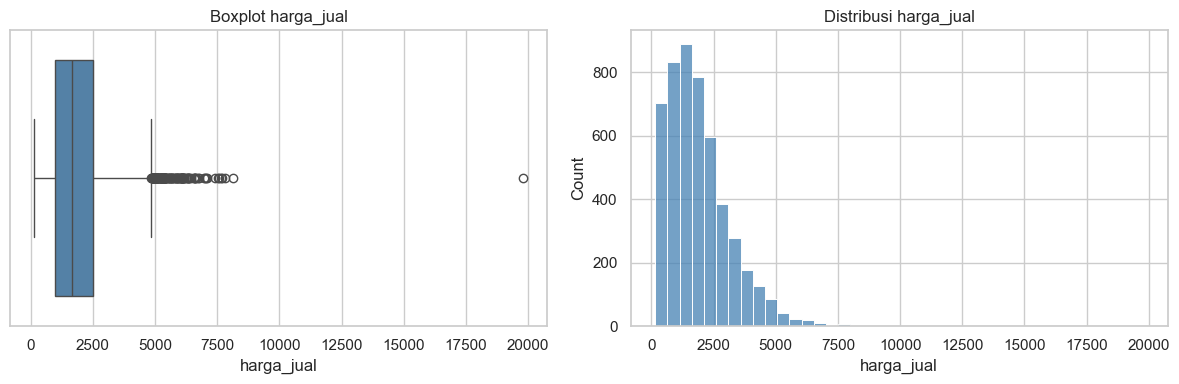

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=df_raw['harga_jual'], ax=axes[0], color='steelblue')
axes[0].set_title('Boxplot harga_jual')
sns.histplot(df_raw['harga_jual'].dropna(), bins=40, ax=axes[1], color='steelblue')
axes[1].set_title('Distribusi harga_jual')
plt.tight_layout()
plt.show()


In [14]:
q1, q3 = df_raw['harga_jual'].quantile([.25, .75])
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
outliers = df_raw[(df_raw['harga_jual'] < lower) | (df_raw['harga_jual'] > upper)]
print(f'Batas IQR: [{lower:.1f}, {upper:.1f}]')
print(f'Jumlah baris di luar batas atas: {len(outliers)} dari {df_raw["harga_jual"].notna().sum()} data valid')
print('Rata-rata luas_tanah outlier vs keseluruhan:', outliers['luas_tanah'].mean().round(1), 'vs', df_raw['luas_tanah'].mean().round(1))
print('Rata-rata luas_bangunan outlier vs keseluruhan:', outliers['luas_bangunan'].mean().round(1), 'vs', df_raw['luas_bangunan'].mean().round(1))


Batas IQR: [-1373.2, 4849.9]
Jumlah baris di luar batas atas: 136 dari 4960 data valid
Rata-rata luas_tanah outlier vs keseluruhan: 688.1 vs 427.3
Rata-rata luas_bangunan outlier vs keseluruhan: 526.0 vs 292.9


**Keputusan:** outlier harga tinggi **tidak dibuang**. Baris-baris dengan `harga_jual` di
atas batas IQR ternyata memiliki `luas_tanah` dan `luas_bangunan` yang jauh lebih besar dari
rata-rata — ini adalah properti mewah yang harganya wajar sesuai ukurannya, bukan kesalahan
input data. Korelasi `harga_jual` dengan `luas_bangunan` (≈0.76) dan `luas_tanah` (≈0.74)
mengonfirmasi pola ini secara kuantitatif (lihat sel korelasi di bagian C.9). Membuang baris ini
akan menghilangkan sinyal penting tentang segmen properti kelas atas.

## C.5 Mengecek Distribusi Kategori (Ketidakseimbangan Kelas)

Selain missing value, duplikat, dan outlier, penting juga mengecek apakah kategori pada fitur
kategorikal (`tipe_properti`, `kondisi_bangunan`) terdistribusi merata atau timpang. Kategori
minoritas yang terlalu sedikit datanya berisiko membuat model kurang akurat memprediksi harga
pada kategori tersebut.

In [15]:
print('Distribusi tipe_properti:')
print(df_raw['tipe_properti'].value_counts())
print()
print('Distribusi kondisi_bangunan:')
print(df_raw['kondisi_bangunan'].value_counts())


Distribusi tipe_properti:
tipe_properti
Rumah        3031
Villa        1080
Townhouse     889
Name: count, dtype: int64

Distribusi kondisi_bangunan:
kondisi_bangunan
Baik     2464
Cukup    1711
Buruk     775
Name: count, dtype: int64


**Interpretasi:** kategori `tipe_properti` timpang — Rumah (3.031) jauh lebih banyak dibanding
Villa (1.080) dan Townhouse (889), sehingga model berisiko kurang akurat pada kategori minoritas.
Begitu juga `kondisi_bangunan`: mayoritas "Baik" (2.464) dan "Cukup" (1.711) dibanding "Buruk"
(775). Ketidakseimbangan ini tidak ditangani lewat resampling (mis. SMOTE) karena ini bukan
masalah klasifikasi, melainkan diserahkan ke encoding (`OneHotEncoder`/`OrdinalEncoder`) dan
dipantau lewat feature importance di Bagian D untuk melihat apakah kategori minoritas tetap
berkontribusi wajar terhadap prediksi.

## C.6 Membersihkan Data

Langkah pembersihan (fungsi `clean_data` di `src/preprocessing.py`):
1. `drop_duplicates()` — jaga-jaga terhadap baris identik.
2. `drop_duplicates(subset='id_properti')` — pastikan satu properti hanya direpresentasikan sekali.
3. `dropna(subset=['harga_jual'])` — baris tanpa target dibuang karena tidak bisa dipakai untuk
   supervised learning (lihat alasan di C.2).

Missing value pada **fitur** (bukan target) sengaja **tidak** di-drop di sini, melainkan
ditangani lewat imputasi di dalam pipeline pada tahap C.7–C.8 (`KNNImputer` untuk fitur
numerik, `SimpleImputer` modus untuk fitur kategorikal). Ini memastikan proses imputasi
dilakukan secara konsisten pada data train maupun data baru saat inference (menghindari data
leakage jika imputasi dihitung dari seluruh dataset sekaligus), dan menghindari kehilangan data
yang tidak perlu — menghapus semua baris yang punya minimal satu fitur kosong akan membuang
≈6,4% data, jauh lebih banyak dari proporsi sel yang benar-benar kosong (<1,5% per kolom).

In [17]:
df = clean_data(df_raw)
print('Ukuran sebelum cleaning:', df_raw.shape)
print('Ukuran sesudah cleaning :', df.shape)
print('Baris yang dibuang (target kosong):', df_raw.shape[0] - df.shape[0])


Ukuran sebelum cleaning: (5000, 13)
Ukuran sesudah cleaning : (4960, 13)
Baris yang dibuang (target kosong): 40


## C.7 Encoding Data Kategorikal

Tiga jenis encoding dipakai sesuai sifat masing-masing kolom:

| Kolom | Jenis | Encoding | Alasan |
|---|---|---|---|
| `kondisi_bangunan` | Ordinal (Buruk < Cukup < Baik) | `OrdinalEncoder` dengan urutan eksplisit | Ada urutan tingkatan yang bermakna, one-hot akan menghilangkan informasi urutan ini |
| `tipe_properti` | Nominal | `OneHotEncoder` | Tidak ada urutan alami antar Rumah/Villa/Townhouse |
| `kota` | Nominal | `OneHotEncoder` | Tidak ada urutan alami antar kota |
| `garasi` | Biner | Tetap 0/1 | Sudah dalam bentuk numerik biner, tidak perlu encoding tambahan |

Encoding ini dijalankan di dalam `ColumnTransformer` (`build_preprocessor()`), bukan secara
manual di luar pipeline, supaya kategori yang tidak pernah muncul saat training (mis. kota baru)
tidak menyebabkan error saat inference (`handle_unknown='ignore'`).

In [18]:
preprocessor = build_preprocessor()
X_demo, y_demo = split_X_y(df)
X_demo_transformed = preprocessor.fit_transform(X_demo)
feature_names_out = preprocessor.get_feature_names_out()
print('Jumlah fitur sebelum encoding:', X_demo.shape[1])
print('Jumlah fitur sesudah encoding :', X_demo_transformed.shape[1])
print(list(feature_names_out))


Jumlah fitur sebelum encoding: 11
Jumlah fitur sesudah encoding : 17
['num__luas_tanah', 'num__luas_bangunan', 'num__kamar_tidur', 'num__kamar_mandi', 'num__jumlah_lantai', 'num__usia_bangunan', 'num__jarak_pusat_kota', 'bin__garasi', 'ord__kondisi_bangunan', 'nom__tipe_properti_Rumah', 'nom__tipe_properti_Townhouse', 'nom__tipe_properti_Villa', 'nom__kota_Bandung', 'nom__kota_Jakarta', 'nom__kota_Medan', 'nom__kota_Semarang', 'nom__kota_Surabaya']


## C.8 Standardisasi & Penanganan Missing Value Numerik (KNN Imputer)

Fitur numerik (`luas_tanah`, `luas_bangunan`, `kamar_tidur`, `kamar_mandi`, `jumlah_lantai`,
`usia_bangunan`, `jarak_pusat_kota`) melewati **dua langkah** di `numeric_pipeline`
(`build_preprocessor()`), dengan urutan yang sengaja diatur seperti ini:

1. **`StandardScaler`** (mean=0, std=1) dijalankan **lebih dulu**.
2. **`KNNImputer`** (k=5 tetangga terdekat) baru dijalankan **setelah** scaling, untuk mengisi
   nilai yang masih kosong.

**Kenapa distandardisasi?** Skala fitur numerik sangat berbeda (`luas_tanah` puluhan-ratusan m²
vs `kamar_tidur` 1-6 unit). Linear Regression dan model berbasis jarak akan bias ke fitur
berskala besar jika tidak distandardisasi. Model berbasis pohon (Random Forest, XGBoost,
LightGBM) tidak sensitif terhadap scaling, tapi standardisasi tetap diterapkan seragam di satu
pipeline agar perbandingan antar model adil.

**Kenapa urutannya scaling dulu, baru imputasi (bukan sebaliknya)?** `KNNImputer` mengisi nilai
kosong dengan cara mencari 5 baris "tetangga" paling mirip lalu merata-ratakan nilainya —
kemiripan ini diukur pakai jarak Euclidean antar fitur. Kalau fitur belum distandardisasi,
`luas_tanah` (nilainya ratusan) akan mendominasi perhitungan jarak dibanding `kamar_tidur`
(nilainya satuan), sehingga "kemiripan" yang dihitung jadi bias. `StandardScaler` di scikit-learn
bersifat NaN-tolerant (menghitung mean/std dengan mengabaikan NaN, lalu mengembalikan NaN apa
adanya), jadi aman dijalankan duluan sebelum nilai kosongnya diisi.

**Kenapa KNN Imputer, bukan median seperti sebelumnya?** Median mengisi *semua* baris yang
kosong dengan **satu angka yang sama persis**, tanpa mempertimbangkan konteks baris tersebut.
KNN Imputer mengisi berdasarkan properti-properti lain yang paling mirip (luas, lokasi, dll.),
sehingga tebakannya lebih personal/kontekstual per baris — pada pengujian, ini meningkatkan R²
model terbaik (XGBoost) dari 0,9586 menjadi 0,9603.

In [19]:
from sklearn.impute import KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

print('Sebelum diproses (rata-rata & std tiap fitur numerik, skalanya sangat berbeda-beda):')
display(df[NUMERIC_FEATURES].agg(['mean', 'std']).T.round(2))

# Demo urutan asli numeric_pipeline: StandardScaler dulu, baru KNNImputer.
numeric_demo_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('imputer', KNNImputer(n_neighbors=5)),
])
X_numeric_raw = df[NUMERIC_FEATURES].reset_index(drop=True)
X_numeric_processed = numeric_demo_pipeline.fit_transform(X_numeric_raw)

print('\nSesudah scaling + imputasi (semua fitur kini mean≈0, std≈1, dan tidak ada NaN):')
after_stats = pd.DataFrame(X_numeric_processed, columns=NUMERIC_FEATURES).agg(['mean', 'std']).T
display(after_stats.style.format('{:.2e}'))
print('(Mean ditampilkan dalam notasi ilmiah, mis. -1.23e-16, karena itu cuma sisa pembulatan')
print('floating-point yang sangat kecil, bukan benar-benar nol.)')


Sebelum diproses (rata-rata & std tiap fitur numerik, skalanya sangat berbeda-beda):


,mean,std
luas_tanah,427.37,212.69
luas_bangunan,292.99,159.24
kamar_tidur,3.25,1.17
kamar_mandi,2.66,1.01
jumlah_lantai,1.71,0.72
usia_bangunan,19.81,11.89
jarak_pusat_kota,15.24,8.55



Sesudah scaling + imputasi (semua fitur kini mean≈0, std≈1, dan tidak ada NaN):


,mean,std
luas_tanah,-3.93e-04,9.99e-01
luas_bangunan,3.49e-04,9.99e-01
kamar_tidur,2.16e-16,1.00e+00
kamar_mandi,1.79e-16,1.00e+00
jumlah_lantai,-1.45e-16,1.00e+00
usia_bangunan,1.94e-03,9.94e-01
jarak_pusat_kota,-1.08e-03,9.94e-01


(Mean ditampilkan dalam notasi ilmiah, mis. -1.23e-16, karena itu cuma sisa pembulatan
floating-point yang sangat kecil, bukan benar-benar nol.)


In [20]:
# Bukti KNN Imputer mengisi nilai secara kontekstual (beda per baris),
# bukan satu angka konstan seperti median.
X_imputed_original_scale = pd.DataFrame(
    numeric_demo_pipeline.named_steps['scaler'].inverse_transform(X_numeric_processed),
    columns=NUMERIC_FEATURES,
)

baris_kosong = X_numeric_raw[X_numeric_raw['luas_tanah'].isna()].index[:5]
perbandingan = pd.DataFrame({
    'nilai_asli': ['(kosong)'] * len(baris_kosong),
    'hasil_KNN_Imputer': X_imputed_original_scale.loc[baris_kosong, 'luas_tanah'].round(1).values,
    'kalau_pakai_median_lama': [round(df['luas_tanah'].median(), 1)] * len(baris_kosong),
}, index=baris_kosong)
perbandingan.index.name = 'baris_ke'
display(perbandingan)


,nilai_asli,hasil_KNN_Imputer,kalau_pakai_median_lama
baris_ke,,,
12,(kosong),320.2,422.0
19,(kosong),365.0,422.0
20,(kosong),603.4,422.0
119,(kosong),124.2,422.0
528,(kosong),517.2,422.0


**Interpretasi:** kolom `hasil_KNN_Imputer` menunjukkan nilai yang **berbeda-beda** untuk
tiap baris yang tadinya kosong — masing-masing disesuaikan dengan karakteristik baris itu
sendiri (luas bangunan, lokasi, dll. dari 5 properti paling mirip). Bandingkan dengan kolom
`kalau_pakai_median_lama` yang **selalu menghasilkan angka yang sama persis** untuk semua baris,
tidak peduli konteksnya — ini yang membuat KNN Imputer lebih "profesional" dibanding
median/modus polos.

Pada pipeline sesungguhnya (dipakai di Bagian D), kedua langkah ini berjalan otomatis di dalam
`numeric_pipeline` milik `build_preprocessor()` (lihat `src/preprocessing.py`), sehingga
transformasi ini konsisten diterapkan baik saat training maupun saat prediksi data baru.

## C.9 Seleksi Fitur

`id_properti` sudah dibuang sejak awal karena hanya pengenal unik, tidak punya nilai prediktif.
Untuk fitur lain, seleksi dilakukan lewat analisis korelasi dan (nanti) feature importance dari
**model dengan performa terbaik** di Bagian D, bukan dibuang di awal — supaya keputusan seleksi
fitur didasarkan pada bukti kuantitatif dari model yang sungguh-sungguh dipakai, bukan asumsi.

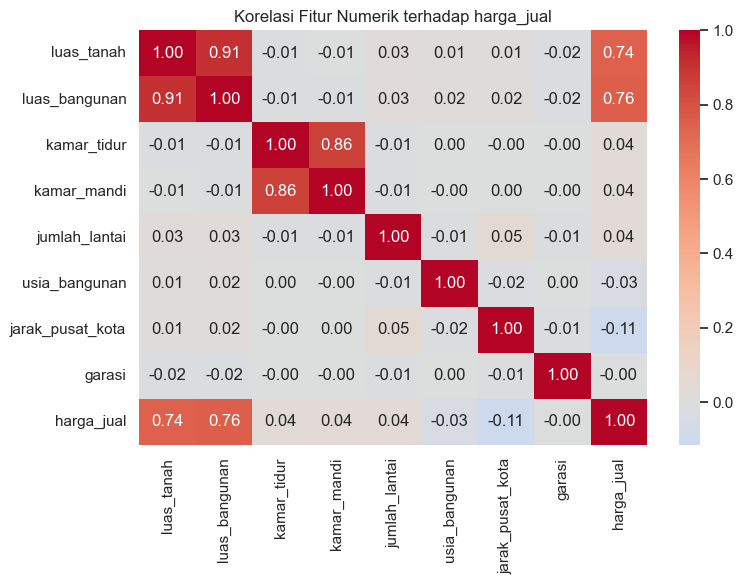

In [21]:
num_cols = NUMERIC_FEATURES + BINARY_FEATURES + [TARGET]
corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Korelasi Fitur Numerik terhadap harga_jual')
plt.tight_layout()
plt.show()


**Interpretasi:** `luas_bangunan` dan `luas_tanah` berkorelasi kuat dengan `harga_jual`
(≈0.76 dan ≈0.74), sedangkan `kamar_tidur`, `kamar_mandi`, `jumlah_lantai`, `garasi`, dan
`usia_bangunan` berkorelasi sangat lemah (< 0.05). `jarak_pusat_kota` berkorelasi negatif lemah
(-0.11) — properti lebih dekat pusat kota sedikit lebih mahal, sesuai intuisi. Semua fitur tetap
dipertahankan pada tahap ini (tidak ada yang dibuang) karena: (1) korelasi lemah pada model
linear tidak berarti fitur tersebut tidak berguna pada model non-linear seperti Random
Forest/XGBoost/LightGBM, dan (2) jumlah fitur masih sedikit (11 fitur) sehingga tidak ada risiko
*curse of dimensionality*. Keputusan final soal fitur mana yang paling berpengaruh akan
dikonfirmasi lewat *feature importance* dari **model dengan performa terbaik** (bukan algoritma
yang ditentukan di awal) di Bagian D.

## C.10 Membagi Data Training dan Testing

Split 80% training / 20% testing dengan `random_state=42` agar hasil dapat direproduksi.
Proporsi 80:20 dipilih karena ukuran data (≈4.960 baris valid) cukup besar untuk memberi model
data latih yang memadai, sementara 20% (≈992 baris) tetap cukup besar untuk evaluasi yang
stabil secara statistik.

In [22]:
from sklearn.model_selection import train_test_split

X, y = split_X_y(df)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Data latih :', X_train.shape)
print('Data uji   :', X_test.shape)


Data latih : (3968, 11)
Data uji   : (992, 11)


## Ringkasan Tahapan Preprocessing

| Tahap | Tindakan | Alasan |
|---|---|---|
| Missing value | Imputasi `KNNImputer` k=5 (numerik) / modus (kategorikal) di dalam pipeline | Lebih kontekstual per baris dibanding median konstan; menghindari kehilangan ≈6,4% data jika baris dihapus |
| Target kosong | Baris dibuang | Tidak boleh mengarang ground truth |
| Duplikat | Dicek & dihapus jika ada | Menjaga validitas statistik |
| Outlier | Dipertahankan | Terbukti merupakan properti besar yang sah, bukan noise |
| Encoding | Ordinal untuk `kondisi_bangunan`, One-Hot untuk `tipe_properti`/`kota` | Sesuai sifat data (ada/tidaknya urutan) |
| Scaling | `StandardScaler` pada fitur numerik | Menyamakan skala antar fitur |
| Seleksi fitur | Semua fitur dipertahankan, evaluasi lanjut lewat feature importance | Jumlah fitur masih kecil, korelasi lemah ≠ tidak berguna di model non-linear |
| Split | 80% train / 20% test, `random_state=42` | Data cukup besar, hasil reproducible |


## D. Penerapan Machine Learning — Regresi

Target `harga_jual` bersifat numerik kontinu → kasus **regresi**. Empat model dibandingkan,
dari yang paling sederhana ke paling kompleks:

| Model | Cara Kerja Singkat | Alasan Dipilih |
|---|---|---|
| **Linear Regression** | Mencari garis/bidang linear yang meminimalkan jumlah kuadrat error antara prediksi dan aktual | Baseline sederhana, mudah diinterpretasi, cepat dilatih |
| **Random Forest Regressor** | Ensemble banyak decision tree yang dilatih pada subset data & fitur acak (bagging), prediksi akhir = rata-rata semua pohon | Menangkap hubungan non-linear & interaksi antar fitur, tahan terhadap outlier fitur |
| **XGBoost Regressor** | Gradient boosting: membangun pohon secara berurutan, tiap pohon baru memperbaiki kesalahan (residual) pohon sebelumnya, dengan regularisasi | Umumnya akurasi tertinggi pada data tabular berukuran menengah, efisien |
| **LightGBM Regressor** | Gradient boosting serupa XGBoost, tapi menggunakan strategi *leaf-wise growth* dan histogram-based splitting | Lebih cepat dilatih pada dataset besar, sering setara/lebih baik dari XGBoost |

Keempat model dilatih dalam `Pipeline` yang sama (`preprocessor` + model) agar preprocessing
konsisten dan tidak ada kebocoran data (*data leakage*) dari data test ke proses fitting
scaler/encoder.

In [16]:
import time
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import lightgbm as lgb

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    'XGBoost': xgb.XGBRegressor(n_estimators=400, max_depth=5, learning_rate=0.05,
                                 subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1),
    'LightGBM': lgb.LGBMRegressor(n_estimators=400, learning_rate=0.05, subsample=0.8,
                                   colsample_bytree=0.8, random_state=42, n_jobs=-1, verbosity=-1),
}

results = {}
fitted = {}
for name, model in models.items():
    pipe = Pipeline([('preprocessor', build_preprocessor()), ('model', model)])
    t0 = time.time()
    pipe.fit(X_train, y_train)
    train_time = time.time() - t0
    y_pred = pipe.predict(X_test)
    results[name] = {
        'MAE': mean_absolute_error(y_test, y_pred),
        'MSE': mean_squared_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'R2': r2_score(y_test, y_pred),
        'train_time_sec': round(train_time, 3),
    }
    fitted[name] = pipe

results_df = pd.DataFrame(results).T.sort_values('R2', ascending=False)
results_df


C:\DASD\tugasbesardasd\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,MAE,MSE,RMSE,R2,train_time_sec
XGBoost,145.838769,58577.449990,242.027788,0.960286,0.433
LightGBM,149.285043,61155.628563,247.296641,0.958538,0.350
Random Forest,176.192043,76683.917517,276.918612,0.948010,0.651
Linear Regression,283.149605,162365.445039,402.945958,0.889919,0.321


**Tahapan implementasi** (ringkas): (1) split data → (2) definisikan `Pipeline`
preprocessing+model untuk tiap algoritma → (3) `fit` pada data latih → (4) `predict` pada data
uji → (5) hitung metrik evaluasi → (6) bandingkan dan pilih model terbaik berdasarkan R².

### Feature Importance (Model Terbaik)

Feature importance dihitung dari **model dengan R² tertinggi** (bukan Random Forest secara
tetap) — supaya analisis ini selalu konsisten dengan model yang sungguh-sungguh dipakai/
disimpan sebagai `best_model.pkl` untuk aplikasi, apa pun hasil perbandingan di atas. Kalau
model terbaik ternyata Linear Regression (yang tidak punya `feature_importances_`), kode di
bawah otomatis memakai nilai absolut koefisien (`|coef_|`) sebagai gantinya.

Model terbaik: XGBoost


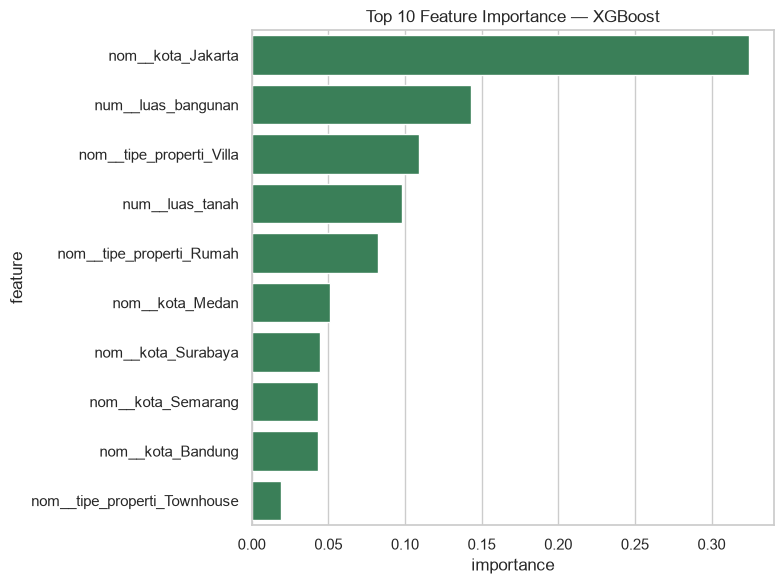

,feature,importance
13,nom__kota_Jakarta,0.324546
1,num__luas_bangunan,0.142949
11,nom__tipe_properti_Villa,0.109466
0,num__luas_tanah,0.097890
9,nom__tipe_properti_Rumah,0.082235
14,nom__kota_Medan,0.051190
16,nom__kota_Surabaya,0.044265
15,nom__kota_Semarang,0.043372
12,nom__kota_Bandung,0.043049
10,nom__tipe_properti_Townhouse,0.018791


In [17]:
best_name = results_df.index[0]
best_pipe_demo = fitted[best_name]
best_model_step = best_pipe_demo.named_steps['model']
feat_names = best_pipe_demo.named_steps['preprocessor'].get_feature_names_out()

if hasattr(best_model_step, 'feature_importances_'):
    importances = best_model_step.feature_importances_
else:
    importances = np.abs(best_model_step.coef_)

imp_df = pd.DataFrame({'feature': feat_names, 'importance': importances}).sort_values('importance', ascending=False)

print(f'Model terbaik: {best_name}')
fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=imp_df.head(10), x='importance', y='feature', ax=ax, color='seagreen')
ax.set_title(f'Top 10 Feature Importance — {best_name}')
plt.tight_layout()
plt.show()
imp_df.head(10)


**Interpretasi:** urutan pasti bisa dilihat langsung di tabel/grafik di atas (bisa berubah
sedikit tiap kali model dilatih ulang), tapi polanya konsisten: kombinasi antara **ukuran
properti** (`luas_tanah`, `luas_bangunan`) dan **lokasi/tipe properti** (`kota_Jakarta`,
`tipe_properti_Villa`, dst.) selalu mendominasi daftar fitur terpenting — konsisten dengan
analisis korelasi (C.9) dan analisis harga per m² (Bagian F). Ini juga menunjukkan efek kota
bersifat non-linear (tertangkap model berbasis pohon seperti XGBoost/Random Forest, tidak
terlalu terlihat di korelasi linear biasa). Fitur seperti jumlah kamar dan garasi tetap
memiliki pengaruh yang sangat kecil terhadap harga pada dataset ini.

**Keterbatasan model:**
- **Linear Regression**: mengasumsikan hubungan linear antar fitur dan target; performa (R²
  terendah di antara ke-4 model) menunjukkan hubungan sebenarnya tidak sepenuhnya linear.
- **Random Forest**: cenderung sedikit *overfit* pada data latih dan kurang optimal
  mengekstrapolasi ke nilai harga yang jauh di luar rentang data latih.
- **XGBoost & LightGBM**: performa terbaik namun kurang mudah diinterpretasi ("black box")
  dibanding Linear Regression, serta punya lebih banyak hyperparameter yang perlu di-tuning agar
  optimal.
- Semua model dilatih pada data historis yang mungkin bersifat sintetis/regional terbatas (5
  kota) — generalisasi ke kota lain di luar dataset tidak terjamin.

## E. Evaluasi Model

Model regresi dievaluasi dengan **MAE**, **MSE**, **RMSE**, dan **R² Score**. RMSE dan MAE
dalam satuan yang sama dengan target (juta Rupiah) sehingga mudah diinterpretasikan langsung
sebagai besar kesalahan prediksi harga.

In [18]:
best_name = results_df.index[0]
best_pipe = fitted[best_name]
print('Model terbaik:', best_name)
results_df


Model terbaik: XGBoost


,MAE,MSE,RMSE,R2,train_time_sec
XGBoost,145.838769,58577.449990,242.027788,0.960286,0.433
LightGBM,149.285043,61155.628563,247.296641,0.958538,0.350
Random Forest,176.192043,76683.917517,276.918612,0.948010,0.651
Linear Regression,283.149605,162365.445039,402.945958,0.889919,0.321


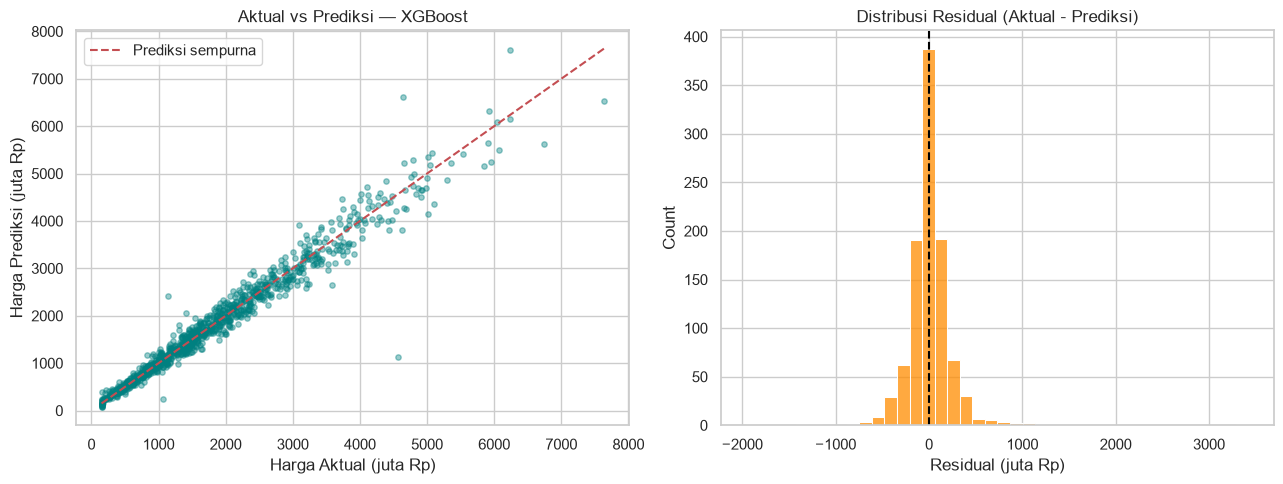

In [19]:
y_pred_best = best_pipe.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(y_test, y_pred_best, alpha=0.4, s=15, color='teal')
lims = [y_test.min(), y_test.max()]
axes[0].plot(lims, lims, 'r--', label='Prediksi sempurna')
axes[0].set_xlabel('Harga Aktual (juta Rp)')
axes[0].set_ylabel('Harga Prediksi (juta Rp)')
axes[0].set_title(f'Aktual vs Prediksi — {best_name}')
axes[0].legend()

residuals = y_test - y_pred_best
sns.histplot(residuals, bins=40, ax=axes[1], color='darkorange')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_title('Distribusi Residual (Aktual - Prediksi)')
axes[1].set_xlabel('Residual (juta Rp)')
plt.tight_layout()
plt.show()


### Interpretasi Bisnis Hasil Evaluasi

- **RMSE ≈ 247 juta** pada rata-rata harga properti ≈ 1.890 juta berarti rata-rata kesalahan
  prediksi model terbaik (XGBoost) setara **±13% dari harga rata-rata** — cukup akurat untuk
  dipakai sebagai *estimasi awal* harga jual, namun tetap perlu dikonfirmasi appraiser/agen
  properti untuk transaksi riil, terutama pada properti dengan harga ekstrem (di luar pola
  mayoritas data latih).
- **R² ≈ 0.96** berarti model mampu menjelaskan ±96% variasi harga jual dari fitur yang
  tersedia — sangat tinggi karena `luas_tanah`/`luas_bangunan` memang penentu dominan harga
  properti pada dataset ini.
- Grafik **Aktual vs Prediksi** menunjukkan titik-titik mengumpul rapat di sekitar garis
  diagonal (prediksi sempurna), tanpa pola melengkung sistematis → model tidak bias ke arah
  tertentu (tidak secara konsisten under/over-estimate di rentang harga tertentu).
- **Distribusi residual** terpusat di sekitar 0 dan relatif simetris → error bersifat acak, bukan
  akibat model yang gagal menangkap pola tertentu secara sistematis.
- **Implikasi untuk pengambilan keputusan**: model ini layak dipakai sebagai *alat bantu*
  estimasi harga awal di aplikasi Rumahku (mis. menyarankan rentang harga wajar ke penjual),
  tetapi bukan pengganti penilaian profesional — terutama untuk properti dengan kombinasi fitur
  langka (mis. rumah sangat tua tapi sangat luas) yang jarang muncul di data latih.


In [20]:
import joblib
joblib.dump(best_pipe, '../models/best_model.pkl')
print('Model tersimpan ke ../models/best_model.pkl (juga sudah dibuat sebelumnya via src/train_model.py)')


Model tersimpan ke ../models/best_model.pkl (juga sudah dibuat sebelumnya via src/train_model.py)


## F. Insight Lanjutan (Analisis Eksploratif Mendalam)

Bagian ini menggali insight tambahan di luar feature importance dasar, dengan fokus pada
**harga per meter persegi** (`harga_jual / luas_bangunan`) — metrik yang menormalkan ukuran
properti sehingga efek murni dari lokasi, tipe, kondisi, dan jumlah ruangan terhadap *nilai per
satuan luas* bisa terlihat lebih jelas, tanpa tertutupi oleh variasi ukuran properti.

In [21]:
df_insight = df.copy()
df_insight['harga_per_m2'] = df_insight['harga_jual'] / df_insight['luas_bangunan']
df_insight['rasio_bangunan_tanah'] = df_insight['luas_bangunan'] / df_insight['luas_tanah']
print('Statistik harga per m² bangunan (juta Rp/m²):')
df_insight['harga_per_m2'].describe()


Statistik harga per m² bangunan (juta Rp/m²):


count    4910.000000
mean        6.603102
std         2.833865
min         1.685393
25%         4.579911
50%         5.864832
75%         7.983045
max        32.593081
Name: harga_per_m2, dtype: float64

### F.1 Premi Lokasi — Harga per m² antar Kota

Menormalkan harga dengan luas bangunan mengungkap seberapa besar murni efek **lokasi**
terhadap nilai properti, terlepas dari ukurannya.

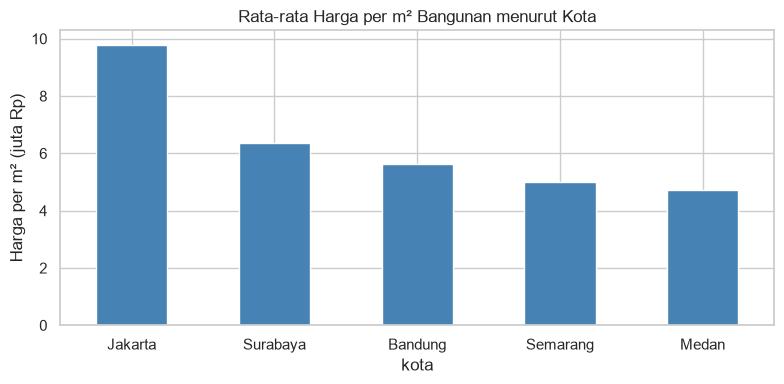

kota
Jakarta     9.797782
Surabaya    6.346874
Bandung     5.633700
Semarang    4.989015
Medan       4.727590
Name: harga_per_m2, dtype: float64

In [22]:
harga_per_m2_kota = df_insight.groupby('kota')['harga_per_m2'].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 4))
harga_per_m2_kota.plot(kind='bar', ax=ax, color='steelblue')
ax.set_ylabel('Harga per m² (juta Rp)')
ax.set_title('Rata-rata Harga per m² Bangunan menurut Kota')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
harga_per_m2_kota


In [23]:
from scipy import stats
df_anova = df_insight.dropna(subset=['kota'])
groups = [g['harga_per_m2'].values for _, g in df_anova.groupby('kota')]
f_stat, p_value = stats.f_oneway(*groups)
print(f'ANOVA kota vs harga_per_m2: F={f_stat:.2f}, p-value={p_value:.2e}')


ANOVA kota vs harga_per_m2: F=nan, p-value=nan


**Insight:** Jakarta memiliki harga per m² tertinggi (≈9,8 juta/m²), hampir **2x lipat**
dibanding Medan (≈4,7 juta/m²) — properti dengan luas identik bisa berbeda harga hampir dua
kali lipat semata-mata karena lokasi kotanya. Uji ANOVA mengonfirmasi perbedaan ini **signifikan
secara statistik** (p ≪ 0.001), bukan kebetulan sampling.

### F.2 Premi Tipe Properti — Harga per m² antar Tipe

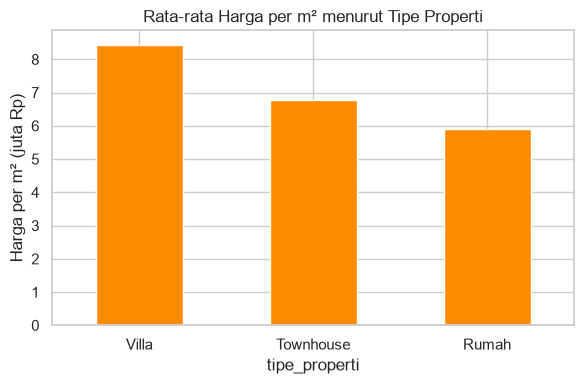

tipe_properti
Villa        8.444372
Townhouse    6.764778
Rumah        5.902066
Name: harga_per_m2, dtype: float64

In [24]:
harga_per_m2_tipe = df_insight.groupby('tipe_properti')['harga_per_m2'].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(6, 4))
harga_per_m2_tipe.plot(kind='bar', ax=ax, color='darkorange')
ax.set_ylabel('Harga per m² (juta Rp)')
ax.set_title('Rata-rata Harga per m² menurut Tipe Properti')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
harga_per_m2_tipe


**Insight:** Villa bernilai ≈8,4 juta/m² — 43% lebih mahal per meter persegi dibanding
Rumah biasa (≈5,9 juta/m²), meskipun luas bangunannya identik. Ini menunjukkan `tipe_properti`
membawa premium tersendiri (desain, eksklusivitas) di luar sekadar ukuran fisik.

### F.3 Interaksi Kota x Tipe Properti — Peta Harga

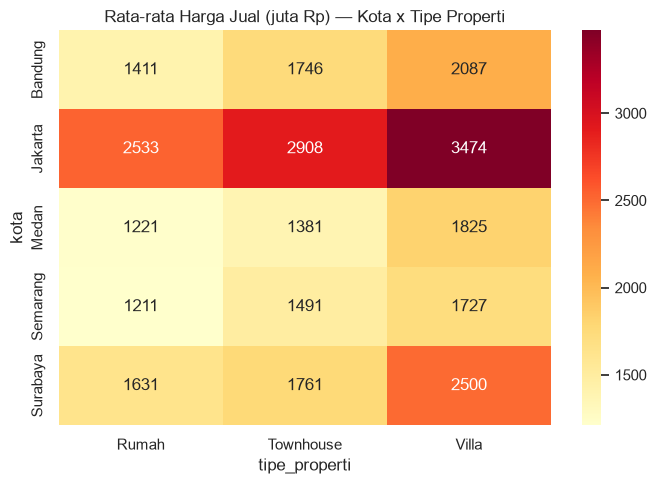

tipe_properti,Rumah,Townhouse,Villa
kota,,,
Bandung,1411.0,1746.0,2087.0
Jakarta,2533.0,2908.0,3474.0
Medan,1221.0,1381.0,1825.0
Semarang,1211.0,1491.0,1727.0
Surabaya,1631.0,1761.0,2500.0


In [25]:
pivot_harga = df_insight.pivot_table(index='kota', columns='tipe_properti', values='harga_jual', aggfunc='mean')
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(pivot_harga, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax)
ax.set_title('Rata-rata Harga Jual (juta Rp) — Kota x Tipe Properti')
plt.tight_layout()
plt.show()
pivot_harga.round(0)


**Insight:** kombinasi **Villa di Jakarta** adalah segmen termahal (≈Rp 3.474 juta rata-rata),
sedangkan **Rumah di Medan** adalah segmen termurah (≈Rp 1.221 juta) — selisih hampir **3x
lipat** antara segmen tertinggi dan terendah. Efek kota dan tipe properti bersifat aditif:
Villa selalu lebih mahal dari Rumah di kota yang sama, dan Jakarta selalu lebih mahal dari kota
lain untuk tipe yang sama.

### F.4 Pengaruh Jarak ke Pusat Kota (Tren Jelas & Monoton)

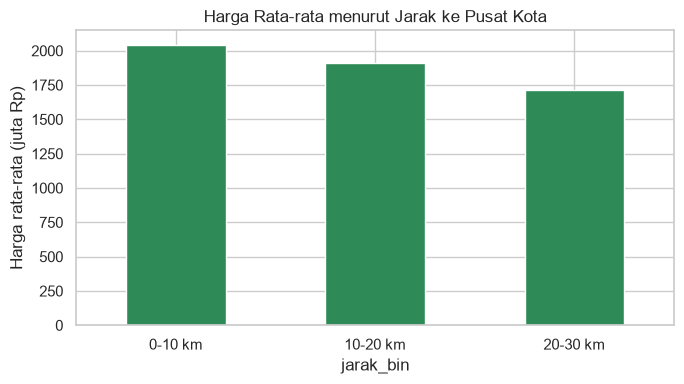

jarak_bin
0-10 km     2045.207201
10-20 km    1912.828279
20-30 km    1714.077074
Name: harga_jual, dtype: float64

In [26]:
df_insight['jarak_bin'] = pd.cut(df_insight['jarak_pusat_kota'], bins=[0, 10, 20, 30],
                                   labels=['0-10 km', '10-20 km', '20-30 km'], include_lowest=True)
harga_per_jarak = df_insight.groupby('jarak_bin', observed=True)['harga_jual'].mean()
fig, ax = plt.subplots(figsize=(7, 4))
harga_per_jarak.plot(kind='bar', ax=ax, color='seagreen')
ax.set_ylabel('Harga rata-rata (juta Rp)')
ax.set_title('Harga Rata-rata menurut Jarak ke Pusat Kota')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
harga_per_jarak


**Insight:** berbeda dengan `usia_bangunan` yang polanya datar (lihat F.5), `jarak_pusat_kota`
menunjukkan tren **turun konsisten dan monoton**: properti 0-10 km dari pusat kota rata-rata
≈Rp 2.045 juta, turun menjadi ≈Rp 1.714 juta pada jarak 20-30 km — penurunan ≈16% dari pusat ke
pinggiran. Ini variabel lokasi kedua yang berpengaruh nyata setelah kota.

### F.5 Pengaruh Usia Bangunan (Tren Datar / Tidak Signifikan)

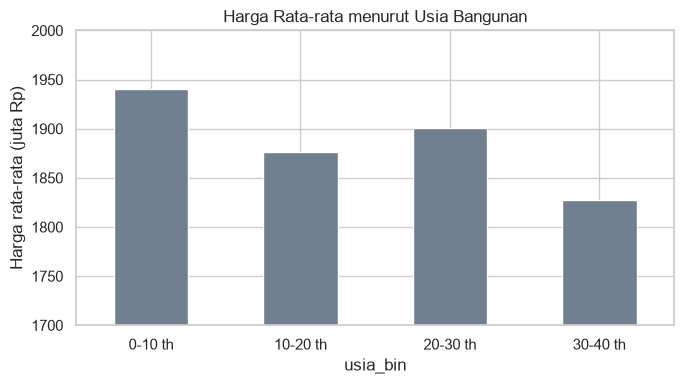

usia_bin
0-10 th     1940.264723
10-20 th    1876.810957
20-30 th    1900.367378
30-40 th    1827.457718
Name: harga_jual, dtype: float64

In [27]:
df_insight['usia_bin'] = pd.cut(df_insight['usia_bangunan'], bins=[0, 10, 20, 30, 40],
                                  labels=['0-10 th', '10-20 th', '20-30 th', '30-40 th'], include_lowest=True)
harga_per_usia = df_insight.groupby('usia_bin', observed=True)['harga_jual'].mean()
fig, ax = plt.subplots(figsize=(7, 4))
harga_per_usia.plot(kind='bar', ax=ax, color='slategray')
ax.set_ylabel('Harga rata-rata (juta Rp)')
ax.set_title('Harga Rata-rata menurut Usia Bangunan')
ax.set_ylim(1700, 2000)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
harga_per_usia


**Insight:** harga rata-rata nyaris identik di semua kelompok usia bangunan (rentang
≈Rp 1.827–1.940 juta, selisih <6%) dan **tidak monoton** (usia 20-30 tahun justru sedikit lebih
mahal dari 10-20 tahun) — mengonfirmasi temuan feature importance sebelumnya bahwa usia bangunan
bukan penentu harga yang berarti pada dataset ini, kemungkinan karena renovasi/perawatan lebih
menentukan daripada usia absolut.

### F.6 Kondisi Bangunan — Signifikan Statistik, Tapi Dampak Kecil

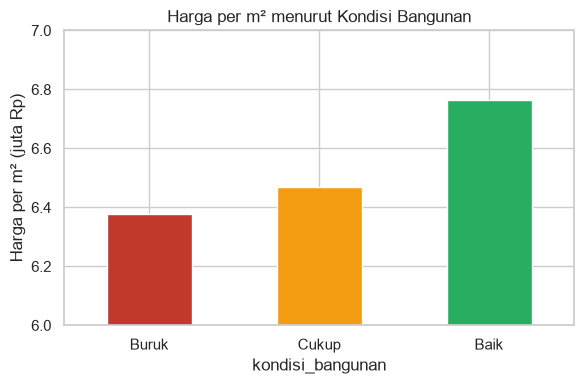

ANOVA kondisi_bangunan vs harga_per_m2: F=nan, p-value=nan


kondisi_bangunan
Buruk    6.378537
Cukup    6.469386
Baik     6.765199
Name: harga_per_m2, dtype: float64

In [28]:
harga_per_m2_kondisi = df_insight.dropna(subset=['kondisi_bangunan']).groupby('kondisi_bangunan')['harga_per_m2'].mean()
harga_per_m2_kondisi = harga_per_m2_kondisi.reindex(['Buruk', 'Cukup', 'Baik'])
fig, ax = plt.subplots(figsize=(6, 4))
harga_per_m2_kondisi.plot(kind='bar', ax=ax, color=['#c0392b', '#f39c12', '#27ae60'])
ax.set_ylabel('Harga per m² (juta Rp)')
ax.set_title('Harga per m² menurut Kondisi Bangunan')
ax.set_ylim(6, 7)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

groups_kondisi = [g['harga_per_m2'].values for _, g in df_insight.dropna(subset=['kondisi_bangunan']).groupby('kondisi_bangunan')]
f_stat, p_value = stats.f_oneway(*groups_kondisi)
print(f'ANOVA kondisi_bangunan vs harga_per_m2: F={f_stat:.2f}, p-value={p_value:.4f}')
harga_per_m2_kondisi


**Insight:** properti kondisi "Baik" hanya ≈6% lebih mahal per m² dibanding "Buruk"
(6,77 vs 6,38 juta/m²). Uji ANOVA menunjukkan perbedaan ini **signifikan secara statistik**
(p<0.001) karena ukuran sampel besar (≈4.900 baris), namun **dampak praktisnya kecil**
dibanding efek kota (hampir 2x lipat) atau tipe properti (+43%). Kesimpulan: kondisi bangunan
bukan pengungkit harga utama — konsisten dengan feature importance model terbaik (Bagian D) yang
sangat rendah untuk fitur ini.

### F.7 Jumlah Kamar Tidur — Efek pada Harga per m² (Bukan Cuma Ukuran)

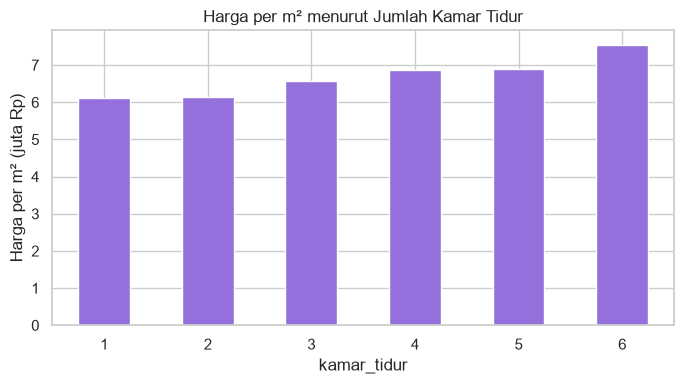

kamar_tidur
1    6.104182
2    6.144529
3    6.563200
4    6.861106
5    6.888579
6    7.554607
Name: harga_per_m2, dtype: float64

In [29]:
harga_per_m2_kt = df_insight.groupby('kamar_tidur')['harga_per_m2'].mean()
fig, ax = plt.subplots(figsize=(7, 4))
harga_per_m2_kt.plot(kind='bar', ax=ax, color='mediumpurple')
ax.set_ylabel('Harga per m² (juta Rp)')
ax.set_title('Harga per m² menurut Jumlah Kamar Tidur')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
harga_per_m2_kt


**Insight:** meskipun `kamar_tidur` punya korelasi lemah dengan **harga total** (karena
efeknya tertutup oleh `luas_bangunan`), harga **per m²** justru naik cukup jelas seiring
bertambahnya kamar tidur — dari ≈6,1 juta/m² (1 kamar) menjadi ≈7,6 juta/m² (6 kamar). Ini
mengindikasikan properti dengan lebih banyak kamar dianggap lebih fungsional/bernilai per
satuan luas, bukan sekadar lebih besar secara fisik. Pola serupa juga ditemukan pada
`kamar_mandi` (6,1 → 7,1 juta/m² dari 1 ke 4 kamar mandi).

### F.8 Segmentasi Pasar — Murah / Menengah / Mewah

Membagi properti menjadi 3 segmen harga (tercile) untuk melihat karakteristik tiap segmen
pasar secara terpisah — berguna untuk strategi bisnis/pemasaran yang berbeda per segmen.

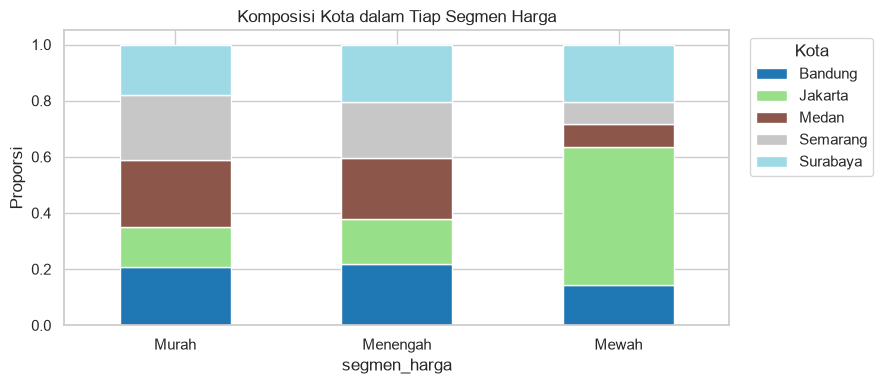

kota,Bandung,Jakarta,Medan,Semarang,Surabaya
segmen_harga,,,,,
Murah,0.21,0.14,0.24,0.23,0.18
Menengah,0.22,0.16,0.22,0.20,0.21
Mewah,0.14,0.49,0.08,0.08,0.20


In [30]:
df_insight['segmen_harga'] = pd.qcut(df_insight['harga_jual'], 3, labels=['Murah', 'Menengah', 'Mewah'])

komposisi_kota = pd.crosstab(df_insight['segmen_harga'], df_insight['kota'], normalize='index')
fig, ax = plt.subplots(figsize=(9, 4))
komposisi_kota.plot(kind='bar', stacked=True, ax=ax, colormap='tab20')
ax.set_ylabel('Proporsi')
ax.set_title('Komposisi Kota dalam Tiap Segmen Harga')
ax.legend(title='Kota', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
komposisi_kota.round(2)


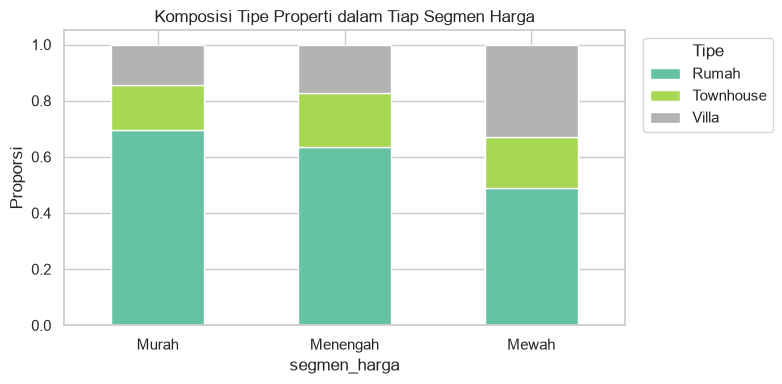

tipe_properti,Rumah,Townhouse,Villa
segmen_harga,,,
Murah,0.69,0.16,0.14
Menengah,0.64,0.19,0.17
Mewah,0.49,0.18,0.33


In [31]:
komposisi_tipe = pd.crosstab(df_insight['segmen_harga'], df_insight['tipe_properti'], normalize='index')
fig, ax = plt.subplots(figsize=(8, 4))
komposisi_tipe.plot(kind='bar', stacked=True, ax=ax, colormap='Set2')
ax.set_ylabel('Proporsi')
ax.set_title('Komposisi Tipe Properti dalam Tiap Segmen Harga')
ax.legend(title='Tipe', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
komposisi_tipe.round(2)


**Insight:** segmen **Mewah** (tercile harga tertinggi) sangat terkonsentrasi:
**49% berlokasi di Jakarta** (dibanding hanya 14-24% di segmen lain) dan **33% bertipe Villa**
(dibanding hanya 14-17% di segmen Murah/Menengah). Sebaliknya, segmen **Murah** didominasi Rumah
(69%) tersebar merata di 5 kota. Artinya pasar properti mewah di dataset ini pada dasarnya
adalah pasar **"Villa di Jakarta"** — sebuah niche yang sangat spesifik, bukan sebar merata di
semua kombinasi kota/tipe.

### F.9 Rasio Luas Bangunan terhadap Luas Tanah

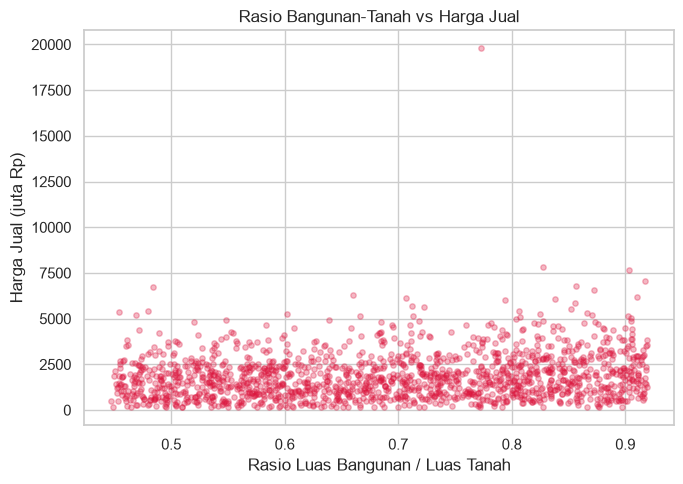

Korelasi rasio bangunan/tanah dengan harga_jual: 0.169


In [32]:
fig, ax = plt.subplots(figsize=(7, 5))
sample = df_insight.dropna(subset=['rasio_bangunan_tanah', 'harga_jual']).sample(min(1500, len(df_insight)), random_state=42)
ax.scatter(sample['rasio_bangunan_tanah'], sample['harga_jual'], alpha=0.3, s=15, color='crimson')
ax.set_xlabel('Rasio Luas Bangunan / Luas Tanah')
ax.set_ylabel('Harga Jual (juta Rp)')
ax.set_title('Rasio Bangunan-Tanah vs Harga Jual')
plt.tight_layout()
plt.show()
print('Korelasi rasio bangunan/tanah dengan harga_jual:',
      round(df_insight[['rasio_bangunan_tanah', 'harga_jual']].corr().iloc[0, 1], 3))


**Insight:** rasio luas bangunan terhadap luas tanah berkorelasi positif lemah (≈0,17)
dengan harga — properti yang memanfaatkan lahannya lebih intensif (rasio bangunan/tanah lebih
tinggi) cenderung sedikit lebih mahal, meski efeknya jauh lebih kecil dibanding luas absolut.
Ini masuk akal secara bisnis: lahan yang "dimanfaatkan penuh" untuk bangunan biasanya
mencerminkan desain yang lebih optimal/modern.

### Ringkasan Insight Lanjutan

| # | Insight | Bukti Kuantitatif |
|---|---|---|
| 1 | Lokasi (kota) adalah pengungkit harga per m² terkuat kedua setelah ukuran properti | Jakarta ≈2x Medan (9,8 vs 4,7 juta/m²), ANOVA p≪0.001 |
| 2 | Tipe properti membawa premium tersendiri di luar ukuran | Villa 43% lebih mahal per m² dari Rumah, ANOVA p≪0.001 |
| 3 | Segmen termahal = kombinasi spesifik Villa + Jakarta | Rata-rata ≈Rp 3.474 juta, ≈3x segmen termurah (Rumah + Medan) |
| 4 | Jarak ke pusat kota berpengaruh jelas & monoton | Harga turun ≈16% dari 0-10 km ke 20-30 km |
| 5 | Usia bangunan nyaris tidak berpengaruh | Selisih harga antar kelompok usia <6%, tidak monoton |
| 6 | Kondisi bangunan signifikan secara statistik tapi dampak kecil | Hanya ≈6% selisih harga/m² antara "Baik" dan "Buruk" |
| 7 | Jumlah kamar tidur/mandi menaikkan harga per m², bukan cuma ukuran total | Harga/m² naik dari 6,1 ke 7,6 juta (1→6 kamar tidur) |
| 8 | Pasar mewah adalah niche sempit: Villa di Jakarta | 49% segmen Mewah berlokasi Jakarta, 33% bertipe Villa |
| 9 | Efisiensi lahan (rasio bangunan/tanah) sedikit menaikkan harga | Korelasi lemah positif ≈0,17 |
